In [10]:
import sys
print(sys.executable)

g:\project\loan_approval\.venv\Scripts\python.exe


In [11]:
import sys
print(sys.version)


3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]


In [12]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "show", "pandas"])

CompletedProcess(args=['g:\\project\\loan_approval\\.venv\\Scripts\\python.exe', '-m', 'pip', 'show', 'pandas'], returncode=0)

In [13]:


import os
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # for training and testing
from sklearn.linear_model import LinearRegression # for using algorithm

In [14]:
df =pd.read_csv(r"G:\project\loan_approval\loan_approval.csv")
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   str    
 1   city            2000 non-null   str    
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 111.5 KB


In [16]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [17]:
df.tail()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False
1999,Nicole Brown,New Nathantown,41188,482,31397,6,20.0,False


In [18]:
df.shape

(2000, 8)

In [19]:
df.columns

Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='str')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   str    
 1   city            2000 non-null   str    
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), str(2)
memory usage: 111.5 KB


In [21]:
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


In [22]:
df.name

0          Allison Hill
1          Brandon Hall
2          Rhonda Smith
3       Gabrielle Davis
4          Valerie Gray
             ...       
1995     James Schaefer
1996          Diana Lin
1997      Brandon Meyer
1998        Jason Price
1999       Nicole Brown
Name: name, Length: 2000, dtype: str

In [23]:
df["income"]

0       113810
1        44592
2        33278
3       127196
4        66048
         ...  
1995     92163
1996     38799
1997     41957
1998    139022
1999     41188
Name: income, Length: 2000, dtype: int64

In [24]:
df[["income"]]

,income
0,113810
1,44592
2,33278
3,127196
4,66048
...,...
1995,92163
1996,38799
1997,41957
1998,139022


In [25]:
df['city'].unique()

<StringArray>
[       'East Jill',    'New Jamesside',     'Lake Roberto',
 'West Melanieview',        'Mariastad',  'Port Jesseville',
      'Lake Joseph',       'Nelsonside',  'Port Leslieview',
   'Wilkersonmouth',
 ...
    'South Kenneth',        'Cookshire',     'Jenniferstad',
          'Basston',        'Tylertown',        'Robertton',
        'New Frank',       'East Haley',         'Adamland',
   'New Nathantown']
Length: 1882, dtype: str

In [26]:
df['income' ].nunique()

1988

In [27]:
df['credit_score'].value_counts()

credit_score
395    10
645    10
468    10
546    10
725     9
       ..
348     1
822     1
788     1
623     1
757     1
Name: count, Length: 537, dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.drop_duplicates()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [30]:
df.drop_duplicates(inplace=True)
                  
                   

In [31]:
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [32]:
char = df.select_dtypes(include=['object','string'])
char

,name,city
0,Allison Hill,East Jill
1,Brandon Hall,New Jamesside
2,Rhonda Smith,Lake Roberto
3,Gabrielle Davis,West Melanieview
4,Valerie Gray,Mariastad
...,...,...
1995,James Schaefer,Robertton
1996,Diana Lin,New Frank
1997,Brandon Meyer,East Haley
1998,Jason Price,Adamland


In [33]:
num = df.select_dtypes(exclude="object")
num

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,False
1,44592,729,15446,28,55.0,False
2,33278,584,11189,13,45.0,False
3,127196,344,48823,29,50.0,False
4,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...
1995,92163,770,12251,13,85.0,True
1996,38799,635,48259,17,40.0,False
1997,41957,763,16752,5,60.0,True
1998,139022,360,24031,35,55.0,False


In [34]:
char['city'].unique()


<StringArray>
[       'East Jill',    'New Jamesside',     'Lake Roberto',
 'West Melanieview',        'Mariastad',  'Port Jesseville',
      'Lake Joseph',       'Nelsonside',  'Port Leslieview',
   'Wilkersonmouth',
 ...
    'South Kenneth',        'Cookshire',     'Jenniferstad',
          'Basston',        'Tylertown',        'Robertton',
        'New Frank',       'East Haley',         'Adamland',
   'New Nathantown']
Length: 1882, dtype: str

In [35]:
total_df = pd.concat([char,num],axis =1)
total_df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [36]:
df=pd.read_csv('loan_approval.csv')


In [56]:
df['loan_amount'] =df['loan_amount'].astype(int)

In [38]:
df['loan_approved'].value_counts()

loan_approved
False    1121
True      879
Name: count, dtype: int64

In [39]:
df.groupby('loan_approved')['income'].mean()

loan_approved
False    83317.456735
True     99855.614334
Name: income, dtype: float64

In [40]:
df.groupby('loan_approved')['credit_score'].median()

loan_approved
False    463.0
True     729.0
Name: credit_score, dtype: float64

In [41]:
df.groupby('loan_approved')['loan_amount'].mean()

loan_approved
False    27293.981267
True     22776.397042
Name: loan_amount, dtype: float64

In [42]:
income=df['income'].to_numpy(int)
loan_approved = df['loan_approved'].to_numpy(int)


In [43]:
np.min(loan_approved)

np.int64(0)

In [44]:
np.mean(income)


np.float64(90585.977)

In [45]:
np.median(income)

np.float64(90387.5)

In [46]:
np.max(income)

np.int64(149964)

In [47]:
np.min(income)

np.int64(30053)

In [48]:
np.std(income)

np.float64(34479.2518601908)

In [49]:
np.var(income)

np.float64(1188818808.838471)

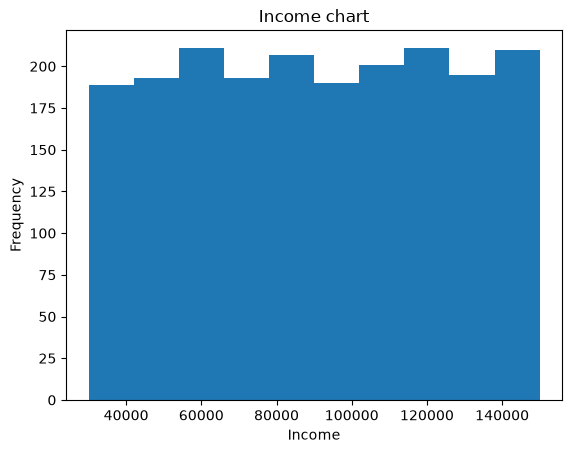

In [50]:
plt.hist(df['income'])
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income chart")
plt.show()


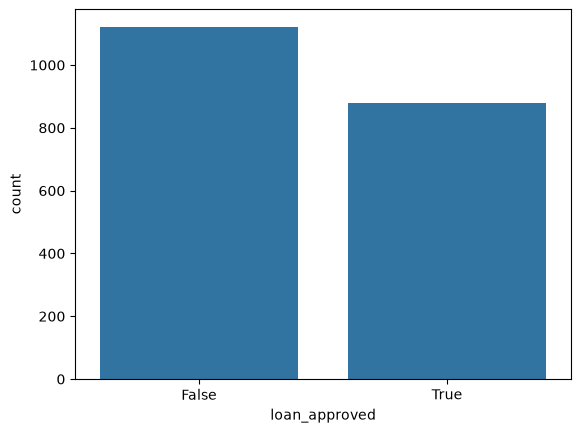

In [51]:
sns.countplot(x='loan_approved',data =df)
plt.show()

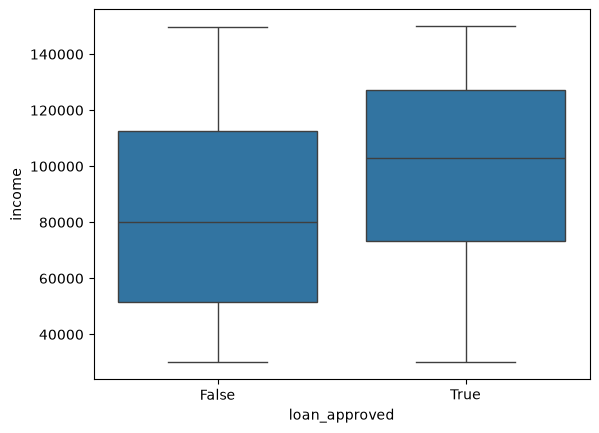

In [52]:
sns.boxplot(x='loan_approved', y='income', data=df)
plt.show()


In [53]:
df.groupby('loan_approved')['income'].mean()


loan_approved
False    83317.456735
True     99855.614334
Name: income, dtype: float64

<Axes: xlabel='loan_approved', ylabel='credit_score'>

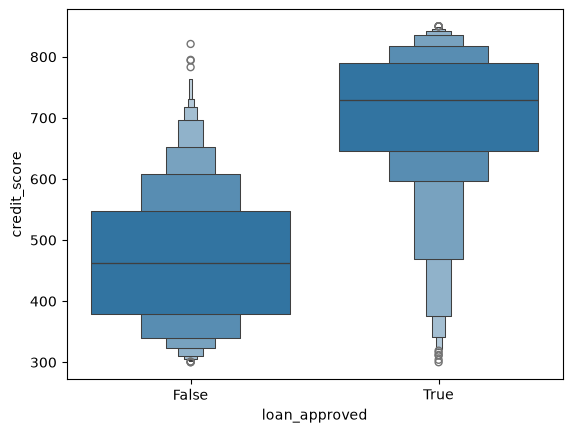

In [54]:
sns.boxenplot(x="loan_approved",y="credit_score",data=df)

<Axes: >

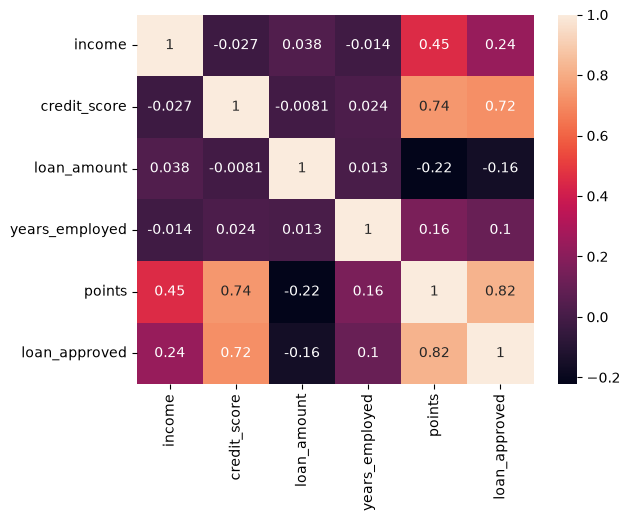

In [55]:
sns.heatmap(df.corr(numeric_only=True),annot=True)